In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses, observableClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 6, 15)) & (dataset.data.index < datetime.datetime(2024, 8, 1)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:
bulk = observableClasses.Bulk(dataset)

Configuration-aware bulk temperature setup:

Configuration: baseline
Time period: 2024-06-15 00:01:00 to 2024-07-31 23:59:00

  System: TGRAD
  Boards 1-4: 1.0, 2.0
  Channels: TE0001, TE0002, TE0003, TE0004, TE0005, TE0006, TE0007, TE0008, TE0009, TE0010 ... (+38 more)

  System: HAWAI
  Boards 1-4: 3.0
  Channels: TE0049, TE0050, TE0051, TE0052, TE0053, TE0054, TE0055, TE0056, TE0057, TE0058 ... (+14 more)

  System: PP
  Boards 1-4: 4.0
  Channels: TE0073, TE0074

  System: PRM
  Boards 1-4: 4.0
  Channels: TE0079, TE0080, TE0081, TE0082, TE0083, TE0084

  System: PIPE
  Boards 1-4: 4.0
  Channels: TE0085, TE0086, TE0087, TE0088, TE0089, TE0090, TE0091, TE0092, TE0093, TE0094 ... (+2 more)


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 10.58sensor/s]

ERROR: Channel (TE0120) not found


In [5]:
bulk.define()


Processing configurations for bulk temperature calculation...

Processing configuration: baseline


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00, 11.35sensor/s]
Calibrating TGRAD Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 48/48 [00:00<00:00, 103.95sensor/s]


      Debug sensor 39666: name='TGRAD1', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39665: name='TGRAD2', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39664: name='TGRAD3', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39667: name='TGRAD4', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39661: name='TGRAD5', system='TGRAD', board=1.0, calibrated=True
    TGRAD: 48 total sensors
      High precision (boards 1-4, calibrated): 48
      Far from inlets (>1500mm): 36
      Far from CE (>1500mm): 36
      Below interface (Y<6100mm): 25
      Final qualifying sensors: 25


Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:01<00:00, 12.38sensor/s]
Calibrating HAWAI Sensors - Calibration Name: FIRST_POFF_PRECISION: 100%|██████████| 24/24 [00:00<00:00, 102.53sensor/s]


    HAWAI: 24 total sensors
      High precision (boards 1-4, calibrated): 24
      Far from inlets (>1500mm): 24
      Far from CE (>1500mm): 16
      Below interface (Y<6100mm): 8
      Final qualifying sensors: 8


...

Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 10.89sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 12/12 [00:00<00:00, 99.29sensor/s]

    PIPE: 12 total sensors
      High precision (boards 1-4, calibrated): 12
      Far from inlets (>1500mm): 4
      Far from CE (>1500mm): 4
      Below interface (Y<6100mm): 4
      Final qualifying sensors: 4


Configuration baseline: 45 sensors included from systems ['TGRAD', 'HAWAI', 'PP', 'PRM', 'PIPE']


In [6]:
print(bulk.bulk)

{'baseline': {'data':                           temp       err
Unnamed: 0                              
2024-06-15 00:01:00        NaN       NaN
2024-06-15 00:02:00        NaN       NaN
2024-06-15 00:03:00  87.648826  0.010283
2024-06-15 00:04:00        NaN       NaN
2024-06-15 00:05:00        NaN       NaN
...                        ...       ...
2024-07-31 23:55:00  87.653024  0.011171
2024-07-31 23:56:00  87.652834  0.010890
2024-07-31 23:57:00  87.652619  0.010363
2024-07-31 23:58:00  87.652564  0.010780
2024-07-31 23:59:00  87.652644  0.010493

[67679 rows x 2 columns], 'sensors': {39651: <src.sensorClasses.Sensor object at 0x1325a5030>, 39650: <src.sensorClasses.Sensor object at 0x1325f0d90>, 40526: <src.sensorClasses.Sensor object at 0x13263fbe0>, 40525: <src.sensorClasses.Sensor object at 0x1326c1720>, 40524: <src.sensorClasses.Sensor object at 0x1335123e0>, 39659: <src.sensorClasses.Sensor object at 0x134faf9d0>, 39658: <src.sensorClasses.Sensor object at 0x134fad780>, 39657: 

{39651: <src.sensorClasses.Sensor object at 0x1325a5030>, 39650: <src.sensorClasses.Sensor object at 0x1325f0d90>, 40526: <src.sensorClasses.Sensor object at 0x13263fbe0>, 40525: <src.sensorClasses.Sensor object at 0x1326c1720>, 40524: <src.sensorClasses.Sensor object at 0x1335123e0>, 39659: <src.sensorClasses.Sensor object at 0x134faf9d0>, 39658: <src.sensorClasses.Sensor object at 0x134fad780>, 39657: <src.sensorClasses.Sensor object at 0x1326b36a0>, 39649: <src.sensorClasses.Sensor object at 0x132e82560>, 39648: <src.sensorClasses.Sensor object at 0x132e92b00>, 39647: <src.sensorClasses.Sensor object at 0x13302b1c0>, 39646: <src.sensorClasses.Sensor object at 0x1330935b0>, 39644: <src.sensorClasses.Sensor object at 0x13449fe20>, 39630: <src.sensorClasses.Sensor object at 0x134443c70>, 39629: <src.sensorClasses.Sensor object at 0x1344c4ac0>, 39628: <src.sensorClasses.Sensor object at 0x1336fce20>, 39627: <src.sensorClasses.Sensor object at 0x13376cd60>, 39626: <src.sensorClasses.Sens

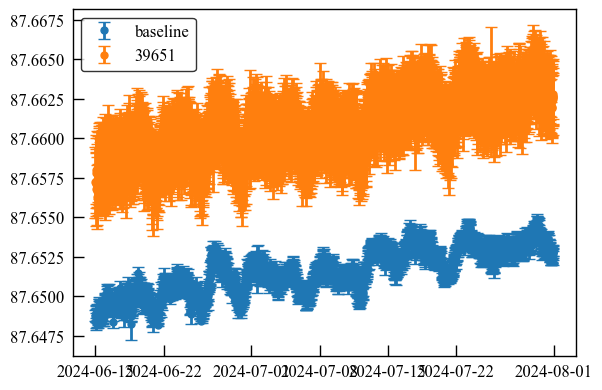

In [18]:
fig, axes = plt.subplots(1,1)
axes.errorbar(bulk.bulk["baseline"]["data"].resample("30min").mean().index, bulk.bulk["baseline"]["data"]["temp"].resample("30min").mean(), yerr=bulk.bulk["baseline"]["data"]["temp"].resample("30min").std(), fmt="o", label="baseline")
print(bulk.bulk["baseline"]["sensors"])
axes.errorbar(bulk.bulk["baseline"]["sensors"][39651].data.resample("30min").mean().index, bulk.bulk["baseline"]["sensors"][39651].data.resample("30min").mean().values, yerr=bulk.bulk["baseline"]["sensors"][39651].data.resample("30min").std().values, fmt="o", label="39651")
axes.legend()
plt.show()